In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.9 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

# Load Model
model = YOLO('yolo11m-seg.pt')

# Train Model
results = model("https://ultralytics.com/images/bus.jpg")




Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 39.2ms
Speed: 2.1ms preprocess, 39.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)


In [9]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55:

In [11]:
for result in results:
    xy = result.masks.xy
    xyn = result.masks.xyn
    masks = result.masks.data
    print(xy)
    print(xyn)
    print(masks)

[array([[     210.94,      227.81],
       [     209.25,       229.5],
       [     204.19,       229.5],
       ...,
       [     275.06,       229.5],
       [     254.81,       229.5],
       [     253.12,      227.81]], dtype=float32), array([[     111.38,      399.94],
       [     104.62,      406.69],
       [     104.62,      408.38],
       [     102.94,      410.06],
       [     102.94,      413.44],
       [     101.25,      415.12],
       [     101.25,      420.19],
       [     99.562,      421.88],
       [     99.562,      430.31],
       [     97.875,         432],
       [     97.875,      440.44],
       [     96.188,      442.12],
       [     96.188,      450.56],
       [       94.5,      452.25],
       [       94.5,      455.62],
       [     92.812,      457.31],
       [     92.812,      460.69],
       [     91.125,      462.38],
       [     91.125,      464.06],
       [     69.188,         486],
       [     69.188,      487.69],
       [     64.125,     

In [12]:
# plot the results on the original image
img_with_masks = results[0].plot()

# or save the plotted image
results[0].save('bus_with_masks.jpg')

'bus_with_masks.jpg'

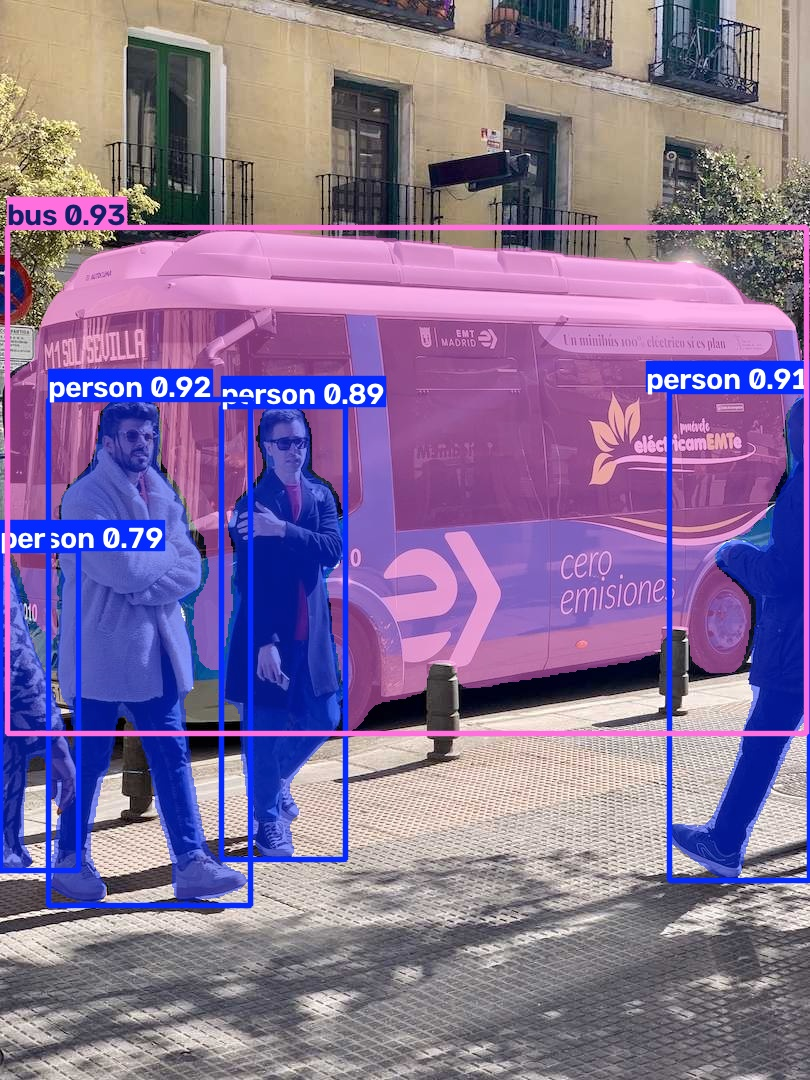

In [14]:
from IPython.display import Image, display
Image(filename='bus_with_masks.jpg')

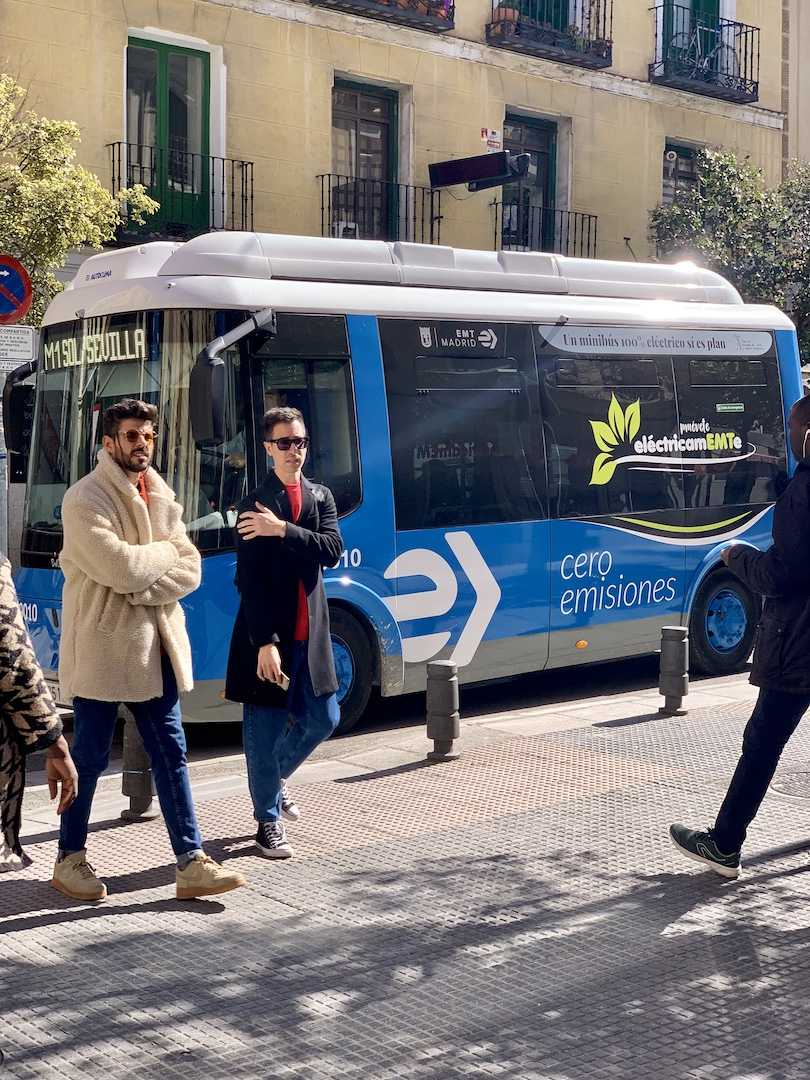

In [16]:
from IPython.display import Image, display
Image(filename='bus.jpg')

## X-large Mode

In [20]:
# Load Model
model1 = YOLO('yolo11x-seg.pt')  # Load an official model

In [21]:
# Train Model
results1 = model1("https://ultralytics.com/images/bus.jpg")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 92.0ms
Speed: 2.3ms preprocess, 92.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)


In [22]:
# plot the results on the original image
img_with_masks = results1[0].plot()

# or save the plotted image
results1[0].save('bus_with_masks1.jpg')

'bus_with_masks1.jpg'

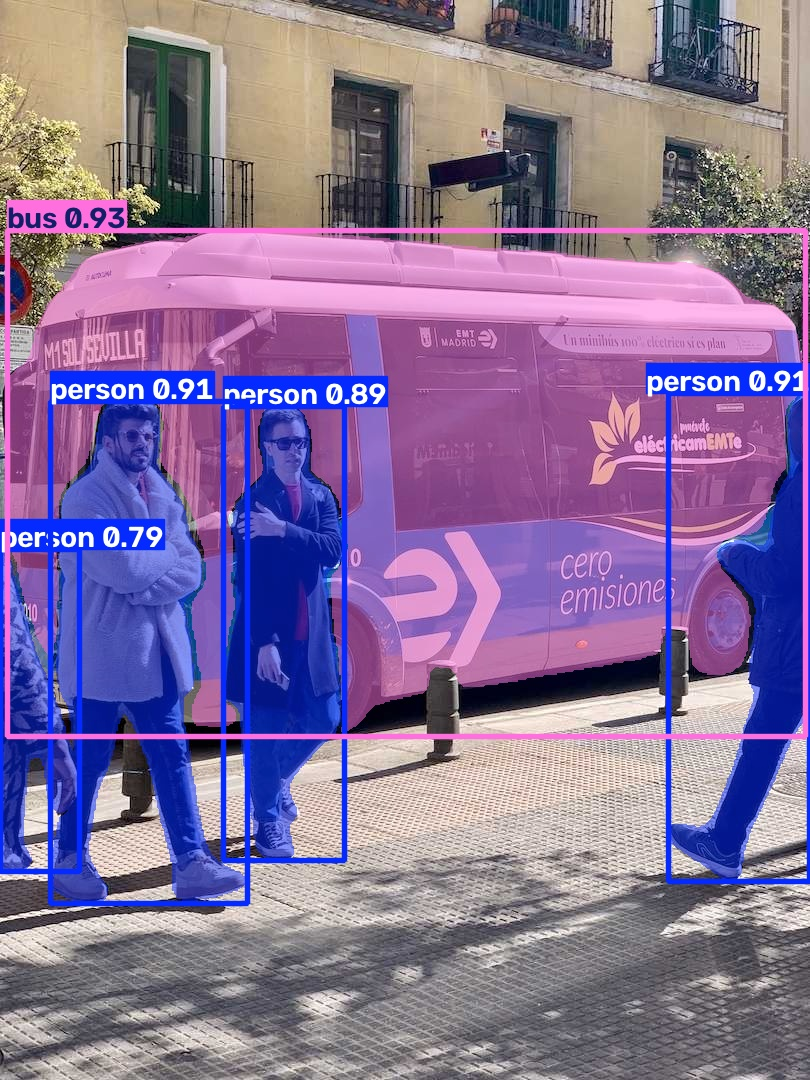

In [23]:
from IPython.display import Image, display
Image(filename='bus_with_masks1.jpg')

In [24]:
import requests
import os


def download_image(url, filename):
  try:
    headers={
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36"
    }
    response = requests.get(url, headers=headers,stream=True)
    response.raise_for_status()
    with open(filename, 'wb') as out_file:
      for chunk in response.iter_content(chunk_size=8192):
        out_file.write(chunk)
    print(f"Image downloaded succesfully to {filename}")
  except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")

download_image("https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg","pexels-photo-13872248.jpg")

Image downloaded succesfully to pexels-photo-13872248.jpg


In [25]:
# check for other images

In [26]:
# Train Model
results2 = model1("/content/pexels-photo-13872248.jpg")


image 1/1 /content/pexels-photo-13872248.jpg: 448x640 6 persons, 1 bottle, 113.7ms
Speed: 3.7ms preprocess, 113.7ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)


In [27]:
# plot the results on the original image
img_with_masks = results2[0].plot()

# or save the plotted image
results2[0].save('persons.jpg')

'persons.jpg'

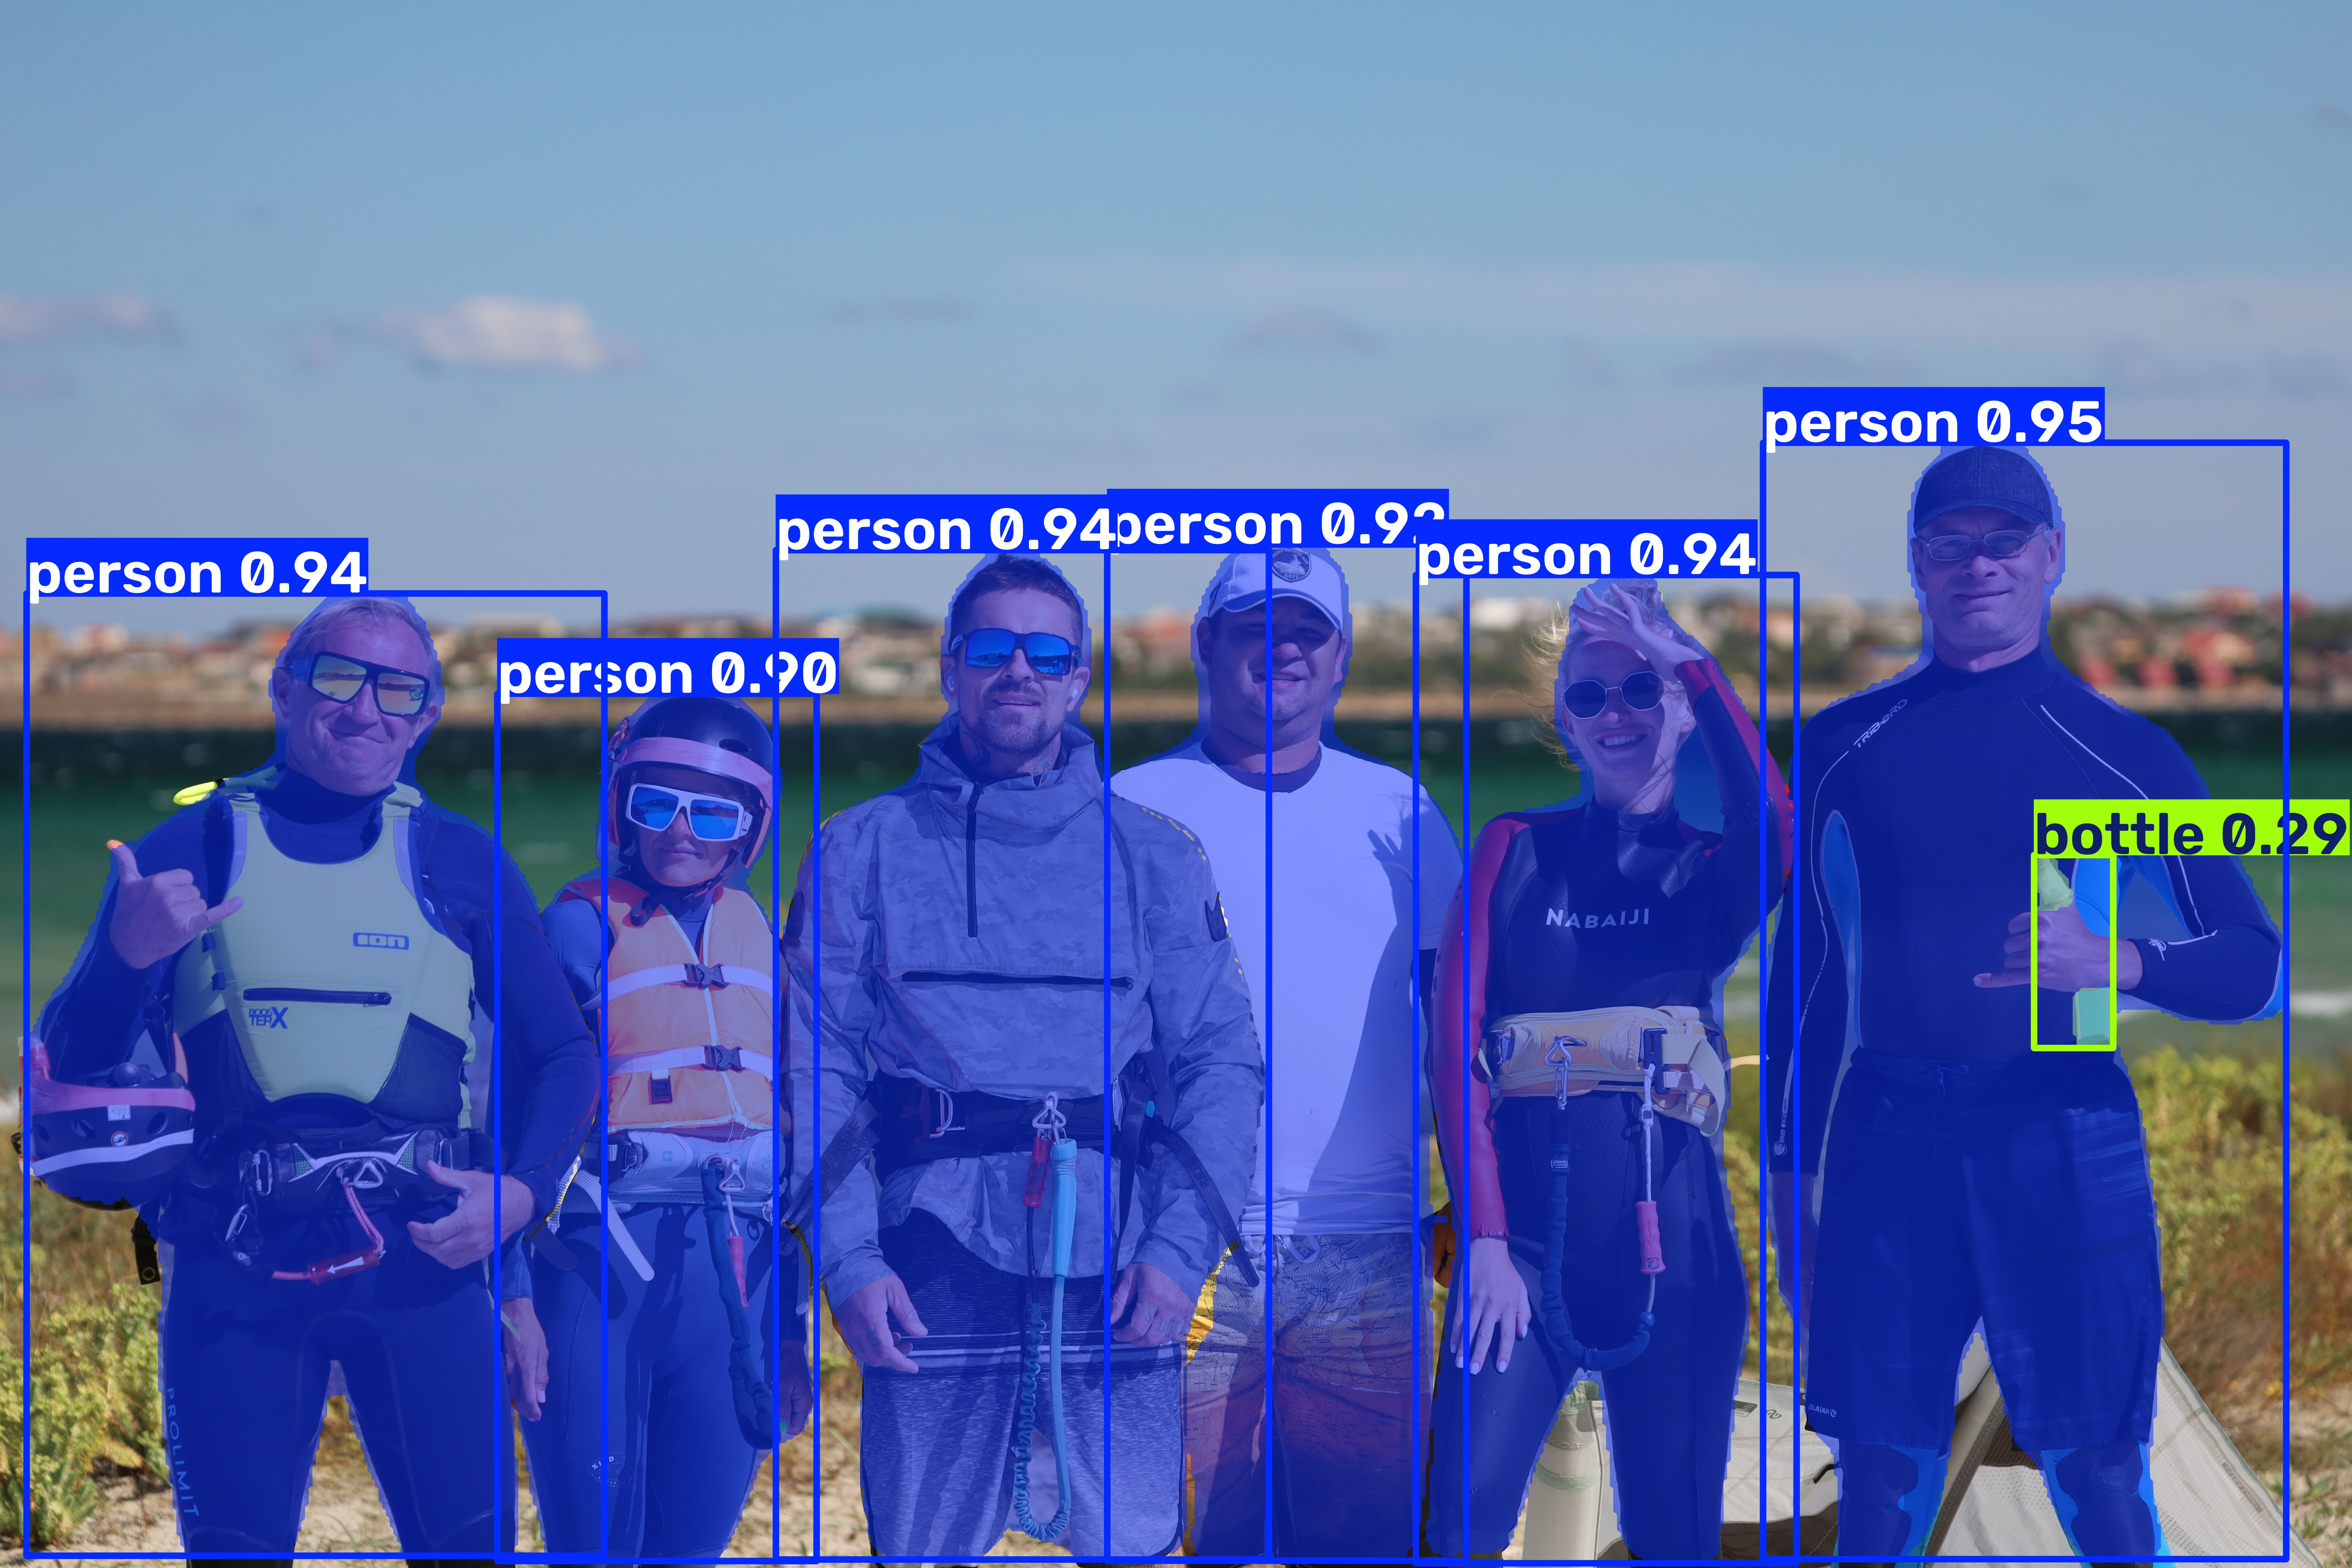

In [28]:
from IPython.display import Image, display
Image(filename='persons.jpg')